### 1. Import Libraries and Load MNIST Dataset

First, we'll import the necessary libraries, including TensorFlow/Keras for building the neural network, and load the MNIST dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)


### 2. Preprocess the Data

We need to flatten the 28x28 images into a 784-dimensional vector and normalize the pixel values to be between 0 and 1. This is a common practice for neural network input.

In [2]:
# Normalize and flatten the images
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"Flattened and normalized x_train shape: {x_train.shape}")
print(f"Flattened and normalized x_test shape: {x_test.shape}")

Flattened and normalized x_train shape: (60000, 784)
Flattened and normalized x_test shape: (10000, 784)


### 3. Build the Sparse Autoencoder Model

A sparse autoencoder aims to find a sparse representation of the input data. We'll achieve this by adding an L1 activity regularizer to the activations of the encoder's hidden layer. This penalty encourages many of the neuron activations to be zero.

In [3]:
# Define the input dimension
input_dim = x_train.shape[1] # 784
encoding_dim = 32 # This is the dimension of the sparse representation

# Input Layer
input_img = Input(shape=(input_dim,))

# Encoder Layer with L1 regularization for sparsity
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(10e-5))(input_img)

# Decoder Layer
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder Model
autoencoder = Model(input_img, decoded)

# Encoder Model (for extracting features)
encoder = Model(input_img, encoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Sparse Autoencoder

Now, we'll train the autoencoder using the training data. The model will try to reconstruct the input, learning a sparse representation in the process.

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.6555 - val_loss: 0.6155
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5832 - val_loss: 0.5535
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5274 - val_loss: 0.5038
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4827 - val_loss: 0.4637
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4466 - val_loss: 0.4314
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4174 - val_loss: 0.4050
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3935 - val_loss: 0.3834
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3739 - val_loss: 0.3656
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3577 - val_loss: 0.3508
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3442 - val_loss: 0.3385
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3329 - val_loss: 0.3281
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12m

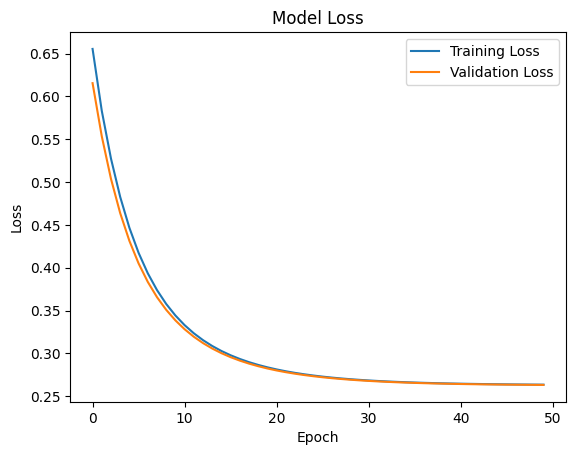

In [4]:
history = autoencoder.fit(x_train, x_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(x_test, x_test))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### 5. Visualize Reconstructions and Sparse Representations

Finally, let's see how well the autoencoder reconstructs the original images and examine the sparse encoding it has learned.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


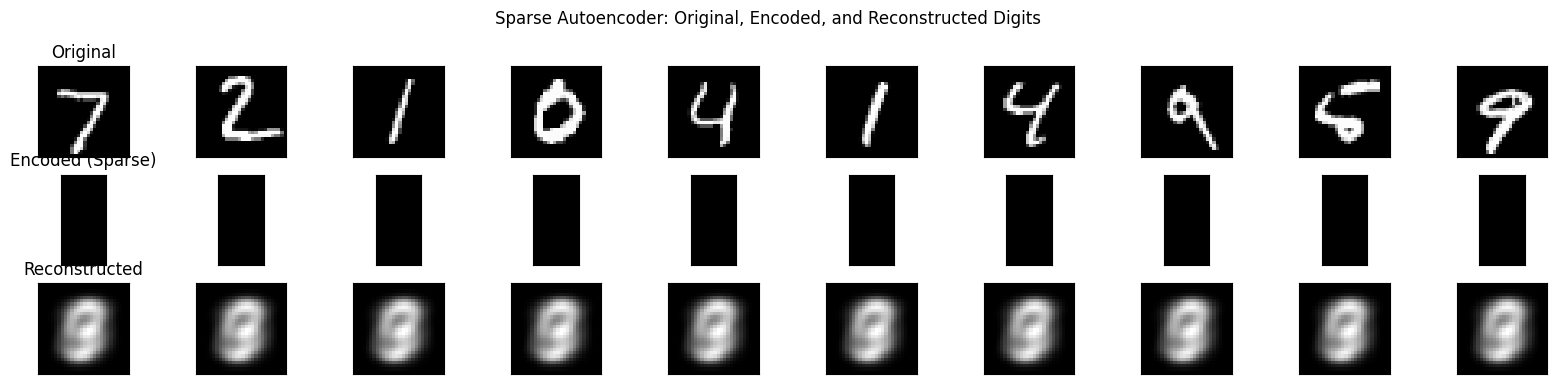

In [5]:
# Encode and decode some digits from the test set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = autoencoder.predict(x_test)

# Display original, encoded (as a heatmap), and reconstructed images
n = 10 # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title('Original')

    # Encoded (sparse representation)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(int(encoding_dim/4), 4)) # Reshape for better visualization
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title('Encoded (Sparse)')

    # Reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title('Reconstructed')

plt.suptitle('Sparse Autoencoder: Original, Encoded, and Reconstructed Digits', y=1.02)
plt.show()